![TecNM](assets/encabezado.png)

---

# Machine Learning y Deep Learning
## Unidad 2 · Modelos de Predicción Supervisados

Práctica 6 — XGBoost: Regresión

> **Facilitador:** Dr. José Gabriel Rodríguez Rivas  
> **Alumno:** Christian Gibran Espituñal Villanueva

---

## Objetivo

Construir, evaluar y optimizar un modelo de **XGBoost** para regresión de precios de vehículos. Se comparan distintas configuraciones de hiperparámetros, se analiza la importancia de variables y se posiciona XGBoost frente a los modelos trabajados en prácticas anteriores.

---

## Marco Teórico

**XGBoost (Extreme Gradient Boosting)** construye un ensamble de $T$ árboles de manera secuencial. Cada árbol $f_t$ corrige los residuos del árbol anterior minimizando una función objetivo regularizada:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} l\left(y_i,\, \hat{y}_i^{(t-1)} + f_t(\mathbf{x}_i)\right) + \Omega(f_t)$$

donde $\Omega(f_t) = \gamma T + \frac{1}{2}\lambda \|\mathbf{w}\|^2$ penaliza la complejidad del árbol. La predicción final es:

$$\hat{y}_i = \sum_{t=1}^{T} \eta \cdot f_t(\mathbf{x}_i)$$

con $\eta$ como tasa de aprendizaje (`learning_rate`).

| Modelo | Linealidad | Flexibilidad | Sobreajuste | Escalable | Interpretabilidad |
|---|---|---|---|---|---|
| Regresión Lineal | Alta | Baja | Baja | Alta | Alta |
| Árbol de Decisión | Baja | Media | Alta | Alta | Media |
| Random Forest | Baja | Alta | Baja | Alta | Baja |
| SVR | Muy Baja | Alta | Baja | Baja | Baja |
| **XGBoost** | **Baja** | **Muy Alta** | **Baja** | **Alta** | **Media** |

---

## Nota sobre GPU

scikit-learn y XGBoost se ejecutan en **CPU** en este notebook. PyTorch se utiliza exclusivamente para detectar y reportar las propiedades del dispositivo CUDA disponible.

---

## Conjunto de Datos

Archivo `datasets/autos2.csv` — especificaciones técnicas y precios de mercado de automóviles.

| Variable | Tipo | Descripción |
|---|---|---|
| `horsepower` | Predictora | Potencia del motor (cv) |
| `engine-size` | Predictora | Cilindrada del motor (cm³) |
| `city-mpg` | Predictora | Consumo urbano (millas/galón) |
| `wheel-base` | Predictora | Distancia entre ejes (pulgadas) |
| `bore` | Predictora | Diámetro del cilindro (pulgadas) |
| `price` | Objetivo | Precio del vehículo (USD) |

---

## Contenido

1. [Entorno y librerías](#1.-Entorno-y-librerías)
2. [Detección de dispositivo (PyTorch)](#2.-Detección-de-dispositivo)
3. [Carga y exploración inicial](#3.-Carga-y-exploración-inicial)
4. [Preprocesamiento y división](#4.-Preprocesamiento-y-división)
5. [Modelo base XGBoost](#5.-Modelo-base-XGBoost)
6. [Modelo con parámetros mejorados](#6.-Modelo-con-parámetros-mejorados)
7. [Análisis de hiperparámetros](#7.-Análisis-de-hiperparámetros)
8. [Optimización con GridSearchCV](#8.-Optimización-con-GridSearchCV)
9. [Modelo optimizado](#9.-Modelo-optimizado)
10. [Importancia de variables](#10.-Importancia-de-variables)
11. [Diagnóstico de residuos](#11.-Diagnóstico-de-residuos)
12. [Comparación de modelos](#12.-Comparación-de-modelos)
13. [Conclusiones](#13.-Conclusiones)

---
## 1. Entorno y librerías

In [17]:
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import scipy.stats as stats
from IPython.display import display

# PyTorch — solo para detección e información del dispositivo CUDA
import torch

from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from statsmodels.nonparametric.smoothers_lowess import lowess

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.28,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'font.family': 'DejaVu Sans',
})

C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE = (
    '#005F9E', '#E87722', '#3DAD6B', '#C0392B', '#8E44AD'
)
PALETTE = [C_BLUE, C_ORANGE, C_GREEN, C_RED, C_PURPLE]
sns.set_theme(style='whitegrid', palette=PALETTE)

RANDOM_STATE = 42
FEATURES     = ['horsepower', 'engine-size', 'city-mpg', 'wheel-base', 'bore']
TARGET       = 'price'
DATASET_PATH = 'datasets/autos2.csv'

print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Detección de dispositivo (PyTorch)

PyTorch se usa exclusivamente para detectar y reportar el hardware CUDA disponible. El entrenamiento de XGBoost ocurre en CPU.

In [18]:
CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE         = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')

rows = [
    ('PyTorch',          torch.__version__),
    ('CUDA disponible',  str(CUDA_AVAILABLE)),
    ('Dispositivo CUDA', str(DEVICE)),
]

if CUDA_AVAILABLE:
    props = torch.cuda.get_device_properties(0)
    rows += [
        ('GPU',          torch.cuda.get_device_name(0)),
        ('Compute cap.', f'sm_{props.major}{props.minor}  ({props.multi_processor_count} SMs)'),
        ('VRAM total',   f'{props.total_memory / 1024**3:.2f} GB'),
        ('CUDA version', torch.version.cuda),
    ]

rows += [
    ('XGBoost backend',   'xgboost.XGBRegressor'),
    ('XGBoost ejecucion', 'CPU  (n_jobs=-1)'),
]

display(
    pd.DataFrame(rows, columns=['Parametro', 'Valor'])
    .style.hide(axis='index')
    .set_caption('Configuracion del entorno de computo')
)

Parametro,Valor
PyTorch,2.10.0+cpu
CUDA disponible,False
Dispositivo CUDA,cpu
XGBoost backend,xgboost.XGBRegressor
XGBoost ejecucion,CPU (n_jobs=-1)


---
## 3. Carga y exploración inicial

In [19]:
df = pd.read_csv(DATASET_PATH)

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
display(df.head())

Dimensiones del dataset: 201 filas x 32 columnas


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,peak-rpm,city-mpg,highway-L/100km,price,city-L/100km,fuel-type_code,diesel,gas,fuel-type-map,horsepower-binned
0,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,13495.0,11.190476,1,False,True,1,Low
1,3,122,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,5000.0,21,8.703704,16500.0,11.190476,1,False,True,1,Low
2,1,122,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,5000.0,19,9.038462,16500.0,12.368421,1,False,True,1,Medium
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,5500.0,24,7.833333,13950.0,9.791667,1,False,True,1,Low
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,5500.0,18,10.681818,17450.0,13.055556,1,False,True,1,Low


In [20]:
display(
    df[FEATURES + [TARGET]]
    .describe().T
    .style.format(precision=2)
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .set_caption('Estadisticas descriptivas')
)

,count,mean,std,min,25%,50%,75%,max
horsepower,201.00,103.40,37.37,48.00,70.00,95.00,116.00,262.00
engine-size,201.00,126.88,41.55,61.00,98.00,120.00,141.00,326.00
city-mpg,201.00,25.18,6.42,13.00,19.00,24.00,30.00,49.00
wheel-base,201.00,98.80,6.07,86.60,94.50,97.00,102.40,120.90
bore,201.00,3.33,0.27,2.54,3.15,3.31,3.58,3.94
price,201.00,13207.13,7947.07,5118.00,7775.00,10295.00,16500.00,45400.00


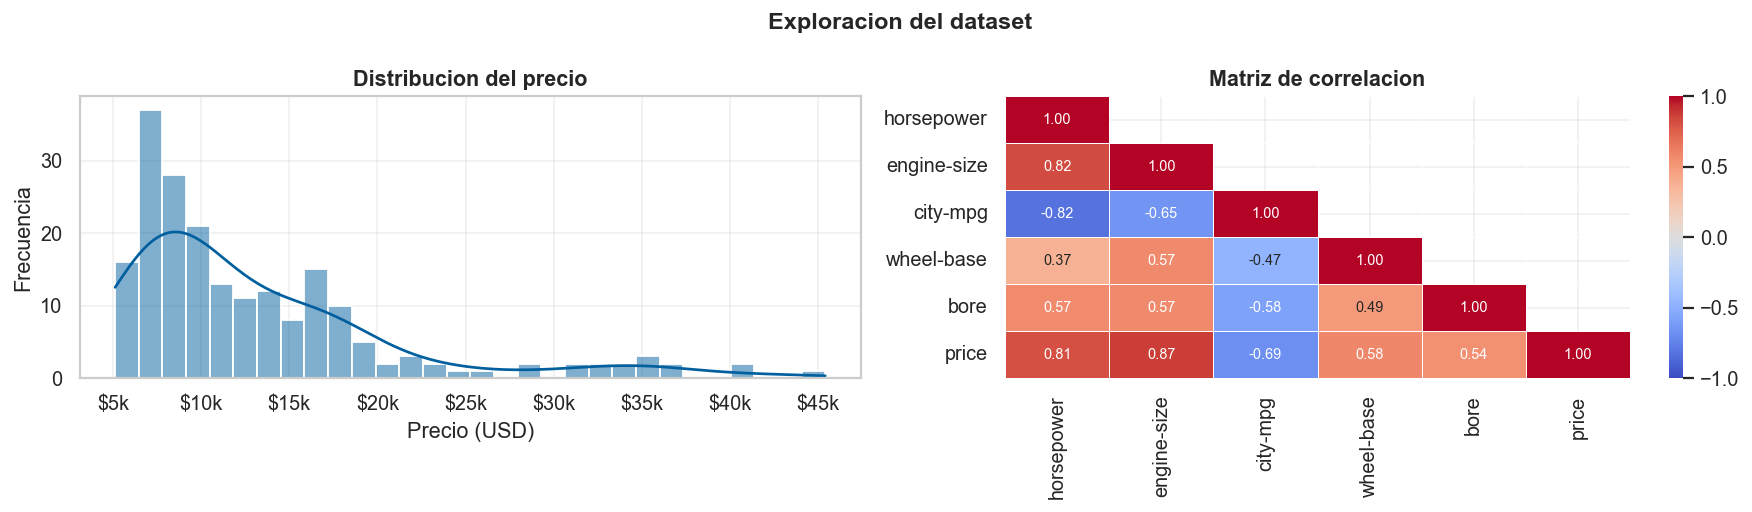

In [21]:
fmt_usd = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')
corr    = df[FEATURES + [TARGET]].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Exploracion del dataset', fontsize=13, fontweight='bold')

sns.histplot(df[TARGET].dropna(), bins=30, kde=True,
             color=C_BLUE, edgecolor='white', ax=axes[0])
axes[0].xaxis.set_major_formatter(fmt_usd)
axes[0].set_title('Distribucion del precio')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=axes[1],
            annot_kws={'size': 8})
axes[1].set_title('Matriz de correlacion')

plt.tight_layout()
plt.show()

---
## 4. Preprocesamiento y división

In [22]:
data = df[FEATURES + [TARGET]].dropna().reset_index(drop=True)

X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f'Total         : {len(data)}')
print(f'Entrenamiento : {len(X_train)} ({len(X_train)/len(data):.0%})')
print(f'Prueba        : {len(X_test)}  ({len(X_test)/len(data):.0%})')
print()
print('XGBoost maneja internamente valores faltantes — no se requiere imputacion.')

Total         : 201
Entrenamiento : 160 (80%)
Prueba        : 41  (20%)

XGBoost maneja internamente valores faltantes — no se requiere imputacion.


---
## 5. Modelo base XGBoost

Configuracion del notebook original: `n_estimators=100`, `learning_rate=0.1`, `max_depth=4`.

  XGBoost base  (n=100, lr=0.1, depth=4)
  ──────────────────────────────────────────────────
  RMSE           : $  3,298.88 USD
  MAE            : $  2,116.10 USD
  R2             :       0.9111
  CV-R2 (5-fold) :       0.8508
  Tiempo ajuste  :     32.49 ms  [CPU]



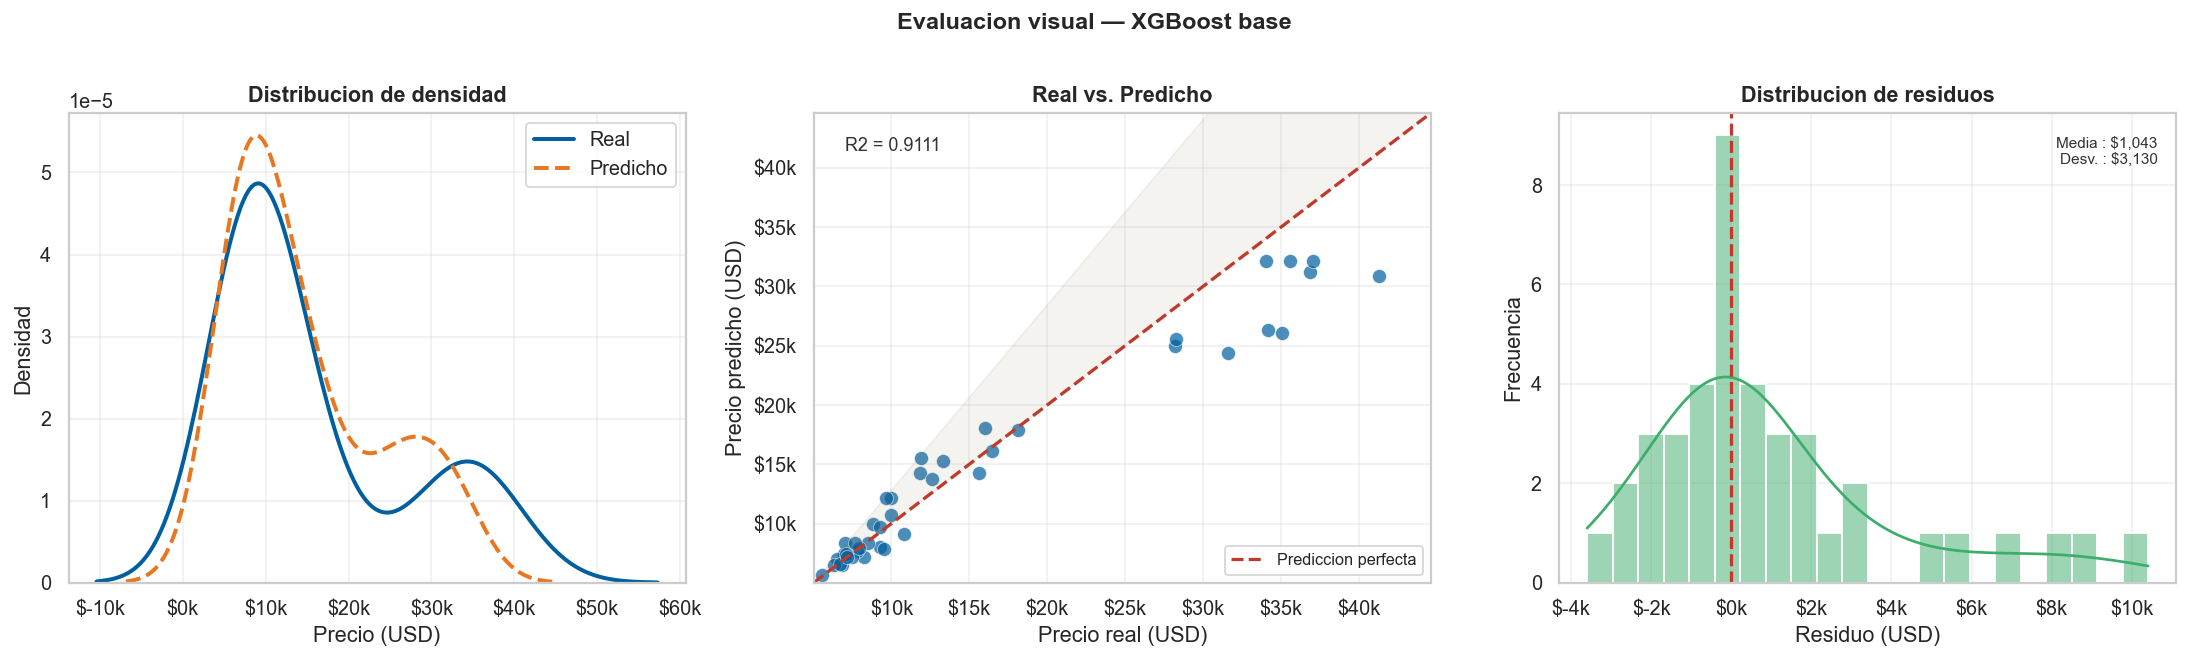

In [23]:
def evaluar(modelo, X_tr, y_tr, X_te, y_te, nombre='Modelo', cv=5):
    """Ajusta el modelo, calcula metricas e imprime resumen."""
    t0    = time.perf_counter()
    modelo.fit(X_tr, y_tr)
    t_fit = (time.perf_counter() - t0) * 1e3

    y_pred = modelo.predict(X_te)
    mse    = mean_squared_error(y_te, y_pred)
    rmse   = np.sqrt(mse)
    mae    = mean_absolute_error(y_te, y_pred)
    r2     = r2_score(y_te, y_pred)
    cv_r2  = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring='r2').mean()

    print(f'  {nombre}')
    print(f'  {"─"*50}')
    print(f'  RMSE           : ${rmse:>10,.2f} USD')
    print(f'  MAE            : ${mae:>10,.2f} USD')
    print(f'  R2             : {r2:>12.4f}')
    print(f'  CV-R2 ({cv}-fold) : {cv_r2:>12.4f}')
    print(f'  Tiempo ajuste  : {t_fit:>9.2f} ms  [CPU]')
    print()
    return {'nombre': nombre, 'mse': mse, 'rmse': rmse,
            'mae': mae, 'r2': r2, 'cv_r2': cv_r2,
            'y_pred': y_pred, 'model': modelo, 't_fit': t_fit}


def panel_evaluacion(y_test, y_pred, titulo=''):
    """Panel de tres graficas: KDE, scatter real vs predicho, residuos."""
    fmt = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    fig.suptitle(f'Evaluacion visual — {titulo}',
                 fontsize=13, fontweight='bold', y=1.01)
    r2_val = r2_score(y_test, y_pred)

    sns.kdeplot(np.asarray(y_test), label='Real',
                color=C_BLUE,   linewidth=2.2, ax=axes[0])
    sns.kdeplot(y_pred, label='Predicho',
                color=C_ORANGE, linewidth=2.2, linestyle='--', ax=axes[0])
    axes[0].xaxis.set_major_formatter(fmt)
    axes[0].set_title('Distribucion de densidad')
    axes[0].set_xlabel('Precio (USD)')
    axes[0].set_ylabel('Densidad')
    axes[0].legend(frameon=True)

    yt  = np.asarray(y_test)
    lim = (min(yt.min(), y_pred.min()) * 0.90,
           max(yt.max(), y_pred.max()) * 1.08)
    axes[1].scatter(yt, y_pred, color=C_BLUE, alpha=0.70,
                    edgecolors='white', linewidths=0.4, s=60)
    axes[1].plot(lim, lim, '--', color=C_RED, linewidth=1.8,
                 label='Prediccion perfecta')
    axes[1].fill_between(lim, lim, [lim[0], lim[1]*1.5], alpha=0.04, color=C_GREEN)
    axes[1].fill_between(lim, [lim[0], lim[1]*1.5], lim,  alpha=0.04, color=C_RED)
    axes[1].xaxis.set_major_formatter(fmt)
    axes[1].yaxis.set_major_formatter(fmt)
    axes[1].set_xlim(*lim)
    axes[1].set_ylim(*lim)
    axes[1].set_title('Real vs. Predicho')
    axes[1].set_xlabel('Precio real (USD)')
    axes[1].set_ylabel('Precio predicho (USD)')
    axes[1].legend(fontsize=9, frameon=True)
    axes[1].text(0.05, 0.92, f'R2 = {r2_val:.4f}',
                 transform=axes[1].transAxes, fontsize=10, color='#333')

    residuos = yt - y_pred
    sns.histplot(residuos, bins=22, kde=True, color=C_GREEN,
                 edgecolor='white', ax=axes[2])
    axes[2].axvline(0, color=C_RED, linestyle='--', linewidth=1.8)
    axes[2].xaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k'))
    axes[2].set_title('Distribucion de residuos')
    axes[2].set_xlabel('Residuo (USD)')
    axes[2].set_ylabel('Frecuencia')
    axes[2].text(0.97, 0.95,
                 f'Media : ${residuos.mean():,.0f}\nDesv. : ${residuos.std():,.0f}',
                 transform=axes[2].transAxes, fontsize=8.5,
                 va='top', ha='right', color='#333')

    plt.tight_layout()
    plt.show()


xgb_base = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=RANDOM_STATE,
    eval_metric='rmse',
)
res_base = evaluar(xgb_base, X_train, y_train, X_test, y_test,
                   nombre='XGBoost base  (n=100, lr=0.1, depth=4)')

panel_evaluacion(y_test, res_base['y_pred'], 'XGBoost base')

---
## 6. Modelo con parámetros mejorados

Aumentar `n_estimators` y reducir `learning_rate` es una estrategia efectiva antes de aplicar GridSearch: mas árboles con pasos mas pequeños generalmente mejoran la generalización.

  XGBoost M2  (n=300, lr=0.05, depth=6)
  ──────────────────────────────────────────────────
  RMSE           : $  3,040.18 USD
  MAE            : $  2,022.94 USD
  R2             :       0.9245
  CV-R2 (5-fold) :       0.8292
  Tiempo ajuste  :    161.04 ms  [CPU]



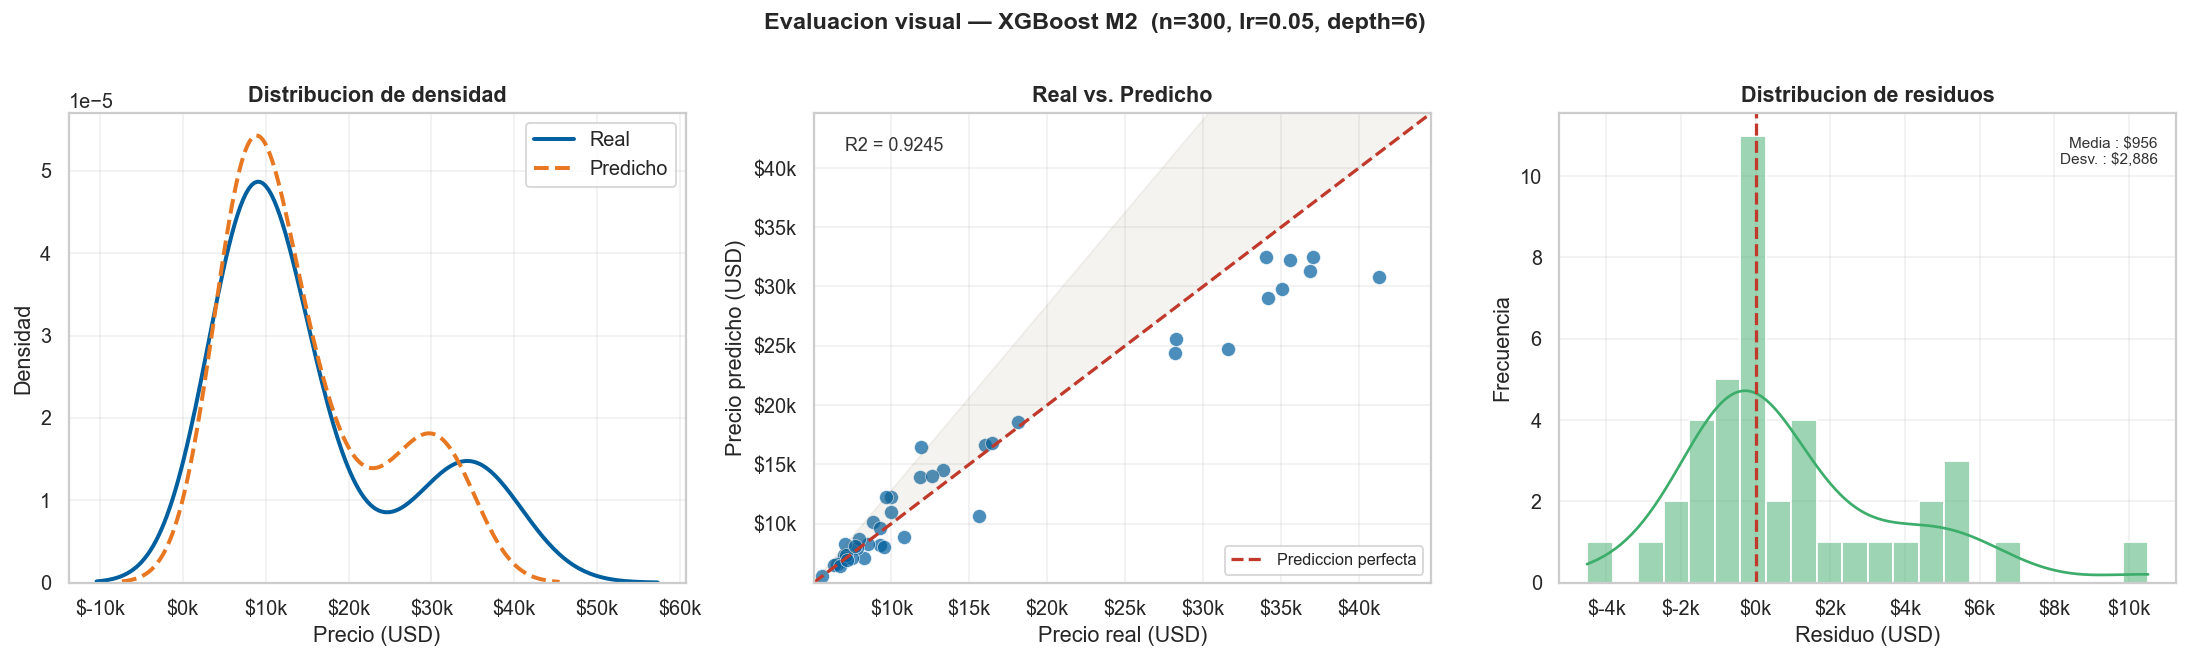

Modelo,RMSE,MAE,R2,CV-R2
"XGBoost base (n=100, lr=0.1, depth=4)","$3,299","$2,116",0.9111,0.8508
"XGBoost M2 (n=300, lr=0.05, depth=6)","$3,040","$2,023",0.9245,0.8292


In [24]:
xgb_m2 = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=RANDOM_STATE,
    eval_metric='rmse',
)
res_m2 = evaluar(xgb_m2, X_train, y_train, X_test, y_test,
                 nombre='XGBoost M2  (n=300, lr=0.05, depth=6)')

panel_evaluacion(y_test, res_m2['y_pred'], 'XGBoost M2  (n=300, lr=0.05, depth=6)')

# Comparativa directa base vs M2
tabla_12 = pd.DataFrame([
    {'Modelo': res_base['nombre'], 'RMSE': res_base['rmse'],
     'MAE': res_base['mae'], 'R2': res_base['r2'], 'CV-R2': res_base['cv_r2']},
    {'Modelo': res_m2['nombre'],   'RMSE': res_m2['rmse'],
     'MAE': res_m2['mae'],   'R2': res_m2['r2'],   'CV-R2': res_m2['cv_r2']},
])
display(
    tabla_12.style
    .format({'RMSE': '${:,.0f}', 'MAE': '${:,.0f}',
             'R2': '{:.4f}', 'CV-R2': '{:.4f}'})
    .highlight_max(subset=['R2', 'CV-R2'], color='#D4EFDF')
    .highlight_min(subset=['RMSE', 'MAE'], color='#D4EFDF')
    .hide(axis='index')
    .set_caption('Comparacion: modelo base vs modelo M2')
)

---
## 7. Análisis de hiperparámetros

Exploración del efecto de `n_estimators` y `learning_rate` sobre R² de entrenamiento y prueba, para entender el compromiso sesgo–varianza antes de la búsqueda exhaustiva.

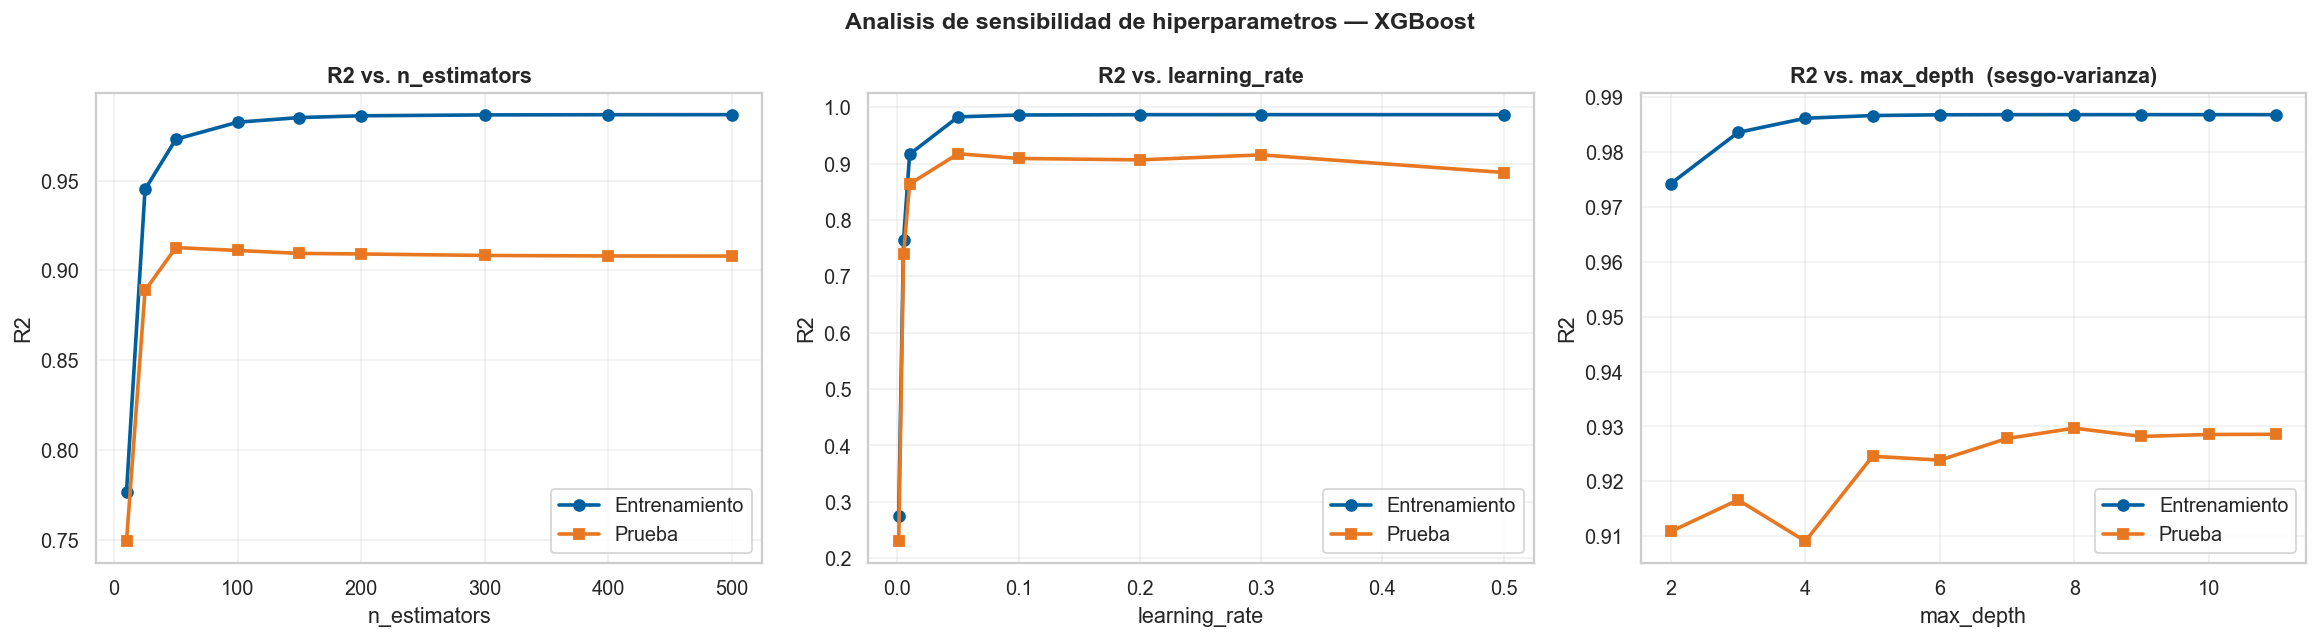

In [25]:
# Efecto de n_estimators
n_range = [10, 25, 50, 100, 150, 200, 300, 400, 500]
scores_n = []
for n in n_range:
    m = XGBRegressor(n_estimators=n, learning_rate=0.1, max_depth=4,
                     random_state=RANDOM_STATE, eval_metric='rmse')
    m.fit(X_train, y_train)
    scores_n.append({
        'n_estimators': n,
        'R2 Train': r2_score(y_train, m.predict(X_train)),
        'R2 Test' : r2_score(y_test,  m.predict(X_test)),
    })
df_n = pd.DataFrame(scores_n)

# Efecto de learning_rate
lr_range = [0.001, 0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
scores_lr = []
for lr in lr_range:
    m = XGBRegressor(n_estimators=200, learning_rate=lr, max_depth=4,
                     random_state=RANDOM_STATE, eval_metric='rmse')
    m.fit(X_train, y_train)
    scores_lr.append({
        'learning_rate': lr,
        'R2 Train': r2_score(y_train, m.predict(X_train)),
        'R2 Test' : r2_score(y_test,  m.predict(X_test)),
    })
df_lr = pd.DataFrame(scores_lr)

# Efecto de max_depth
depth_range = range(2, 12)
scores_d = []
for d in depth_range:
    m = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=d,
                     random_state=RANDOM_STATE, eval_metric='rmse')
    m.fit(X_train, y_train)
    scores_d.append({
        'max_depth': d,
        'R2 Train': r2_score(y_train, m.predict(X_train)),
        'R2 Test' : r2_score(y_test,  m.predict(X_test)),
    })
df_d = pd.DataFrame(scores_d)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analisis de sensibilidad de hiperparametros — XGBoost',
             fontsize=13, fontweight='bold')

for ax, df_cur, x_col, title in zip(
    axes,
    [df_n,          df_lr,           df_d],
    ['n_estimators', 'learning_rate', 'max_depth'],
    ['R2 vs. n_estimators', 'R2 vs. learning_rate', 'R2 vs. max_depth  (sesgo-varianza)']
):
    ax.plot(df_cur[x_col], df_cur['R2 Train'], 'o-',
            color=C_BLUE,   lw=2, label='Entrenamiento')
    ax.plot(df_cur[x_col], df_cur['R2 Test'],  's-',
            color=C_ORANGE, lw=2, label='Prueba')
    ax.set_xlabel(x_col)
    ax.set_ylabel('R2')
    ax.set_title(title)
    ax.legend(frameon=True)

plt.tight_layout()
plt.show()

---
## 8. Optimización con GridSearchCV

Búsqueda exhaustiva sobre 324 combinaciones con validación cruzada de 5 pliegues:

$$3 \times 3 \times 3 \times 3 \times 2 \times 2 = 324 \text{ combinaciones} \times 5 \text{ folds} = 1620 \text{ ajustes}$$

In [26]:
param_grid = {
    'n_estimators'     : [100, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'max_depth'        : [3, 5, 7],
    'min_child_weight' : [1, 5, 10],
    'subsample'        : [0.7, 0.9],
    'colsample_bytree' : [0.7, 0.9],
}

n_combo = 1
for v in param_grid.values():
    n_combo *= len(v)
print(f'Combinaciones a evaluar : {n_combo}')
print(f'Ajustes totales (cv=5)  : {n_combo * 5}')
print()

grid_search = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, eval_metric='rmse'),
    param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1,
    verbose=1,
)

t0 = time.perf_counter()
grid_search.fit(X_train, y_train)
t_gs = time.perf_counter() - t0

best_params = grid_search.best_params_
best_cv_r2  = grid_search.best_score_

print(f'\nTiempo de busqueda      : {t_gs:.1f} s  [CPU n_jobs=-1]')
print(f'Mejor R2 (CV-5)         : {best_cv_r2:.4f}')
print(f'Mejores parametros:')
for k, v in best_params.items():
    print(f'    {k:<20}: {v}')

Combinaciones a evaluar : 324
Ajustes totales (cv=5)  : 1620

Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Tiempo de busqueda      : 79.5 s  [CPU n_jobs=-1]
Mejor R2 (CV-5)         : 0.8769
Mejores parametros:
    colsample_bytree    : 0.7
    learning_rate       : 0.1
    max_depth           : 5
    min_child_weight    : 1
    n_estimators        : 100
    subsample           : 0.9


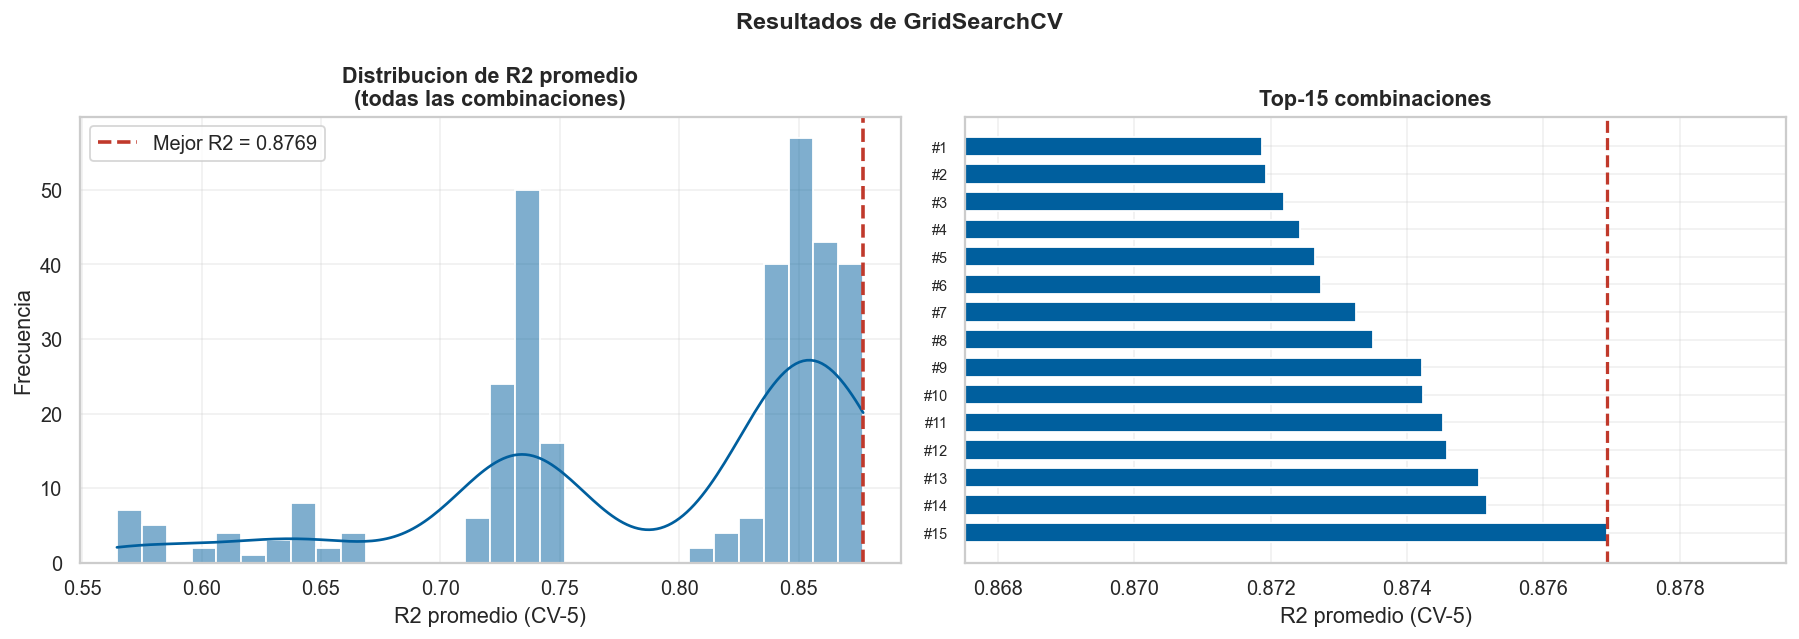

Hiperparametro,Mejor valor,Descripcion
n_estimators,100.000000,Numero de arboles en el ensamble
learning_rate,0.100000,Tasa de aprendizaje — escala la contribucion de cada arbol
max_depth,5.000000,Profundidad maxima de cada arbol — controla sobreajuste
min_child_weight,1.000000,Suma minima de pesos en una hoja — regularizacion
subsample,0.900000,Fraccion de filas usadas por arbol — reduce varianza
colsample_bytree,0.700000,Fraccion de columnas usadas por arbol — reduce correlacion


In [27]:
cv_results = pd.DataFrame(grid_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Resultados de GridSearchCV', fontsize=13, fontweight='bold')

sns.histplot(cv_results['mean_test_score'], bins=30, kde=True,
             color=C_BLUE, edgecolor='white', ax=axes[0])
axes[0].axvline(best_cv_r2, color=C_RED, linestyle='--', linewidth=2,
                label=f'Mejor R2 = {best_cv_r2:.4f}')
axes[0].set_title('Distribucion de R2 promedio\n(todas las combinaciones)')
axes[0].set_xlabel('R2 promedio (CV-5)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend(frameon=True)

top15 = cv_results.nlargest(15, 'mean_test_score').reset_index(drop=True)
axes[1].barh(
    top15.index[::-1], top15['mean_test_score'][::-1],
    color=C_BLUE, edgecolor='white', height=0.7
)
axes[1].axvline(best_cv_r2, color=C_RED, linestyle='--', linewidth=1.8)
axes[1].set_xlabel('R2 promedio (CV-5)')
axes[1].set_title('Top-15 combinaciones')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels([f'#{i+1}' for i in range(14, -1, -1)], fontsize=8)
axes[1].set_xlim(
    top15['mean_test_score'].min() * 0.995,
    top15['mean_test_score'].max() * 1.003
)

plt.tight_layout()
plt.show()

tabla_params = pd.DataFrame([
    {'Hiperparametro': 'n_estimators',     'Mejor valor': best_params['n_estimators'],
     'Descripcion': 'Numero de arboles en el ensamble'},
    {'Hiperparametro': 'learning_rate',    'Mejor valor': best_params['learning_rate'],
     'Descripcion': 'Tasa de aprendizaje — escala la contribucion de cada arbol'},
    {'Hiperparametro': 'max_depth',        'Mejor valor': best_params['max_depth'],
     'Descripcion': 'Profundidad maxima de cada arbol — controla sobreajuste'},
    {'Hiperparametro': 'min_child_weight', 'Mejor valor': best_params['min_child_weight'],
     'Descripcion': 'Suma minima de pesos en una hoja — regularizacion'},
    {'Hiperparametro': 'subsample',        'Mejor valor': best_params['subsample'],
     'Descripcion': 'Fraccion de filas usadas por arbol — reduce varianza'},
    {'Hiperparametro': 'colsample_bytree', 'Mejor valor': best_params['colsample_bytree'],
     'Descripcion': 'Fraccion de columnas usadas por arbol — reduce correlacion'},
])
display(
    tabla_params.style.hide(axis='index')
    .set_caption('Configuracion optima encontrada por GridSearchCV')
)

---
## 9. Modelo optimizado

  XGBoost optimizado  (GridSearchCV)
  ──────────────────────────────────────────────────
  RMSE           : $  3,378.07 USD
  MAE            : $  2,180.45 USD
  R2             :       0.9067
  CV-R2 (5-fold) :       0.8712
  Tiempo ajuste  :    123.91 ms  [CPU]



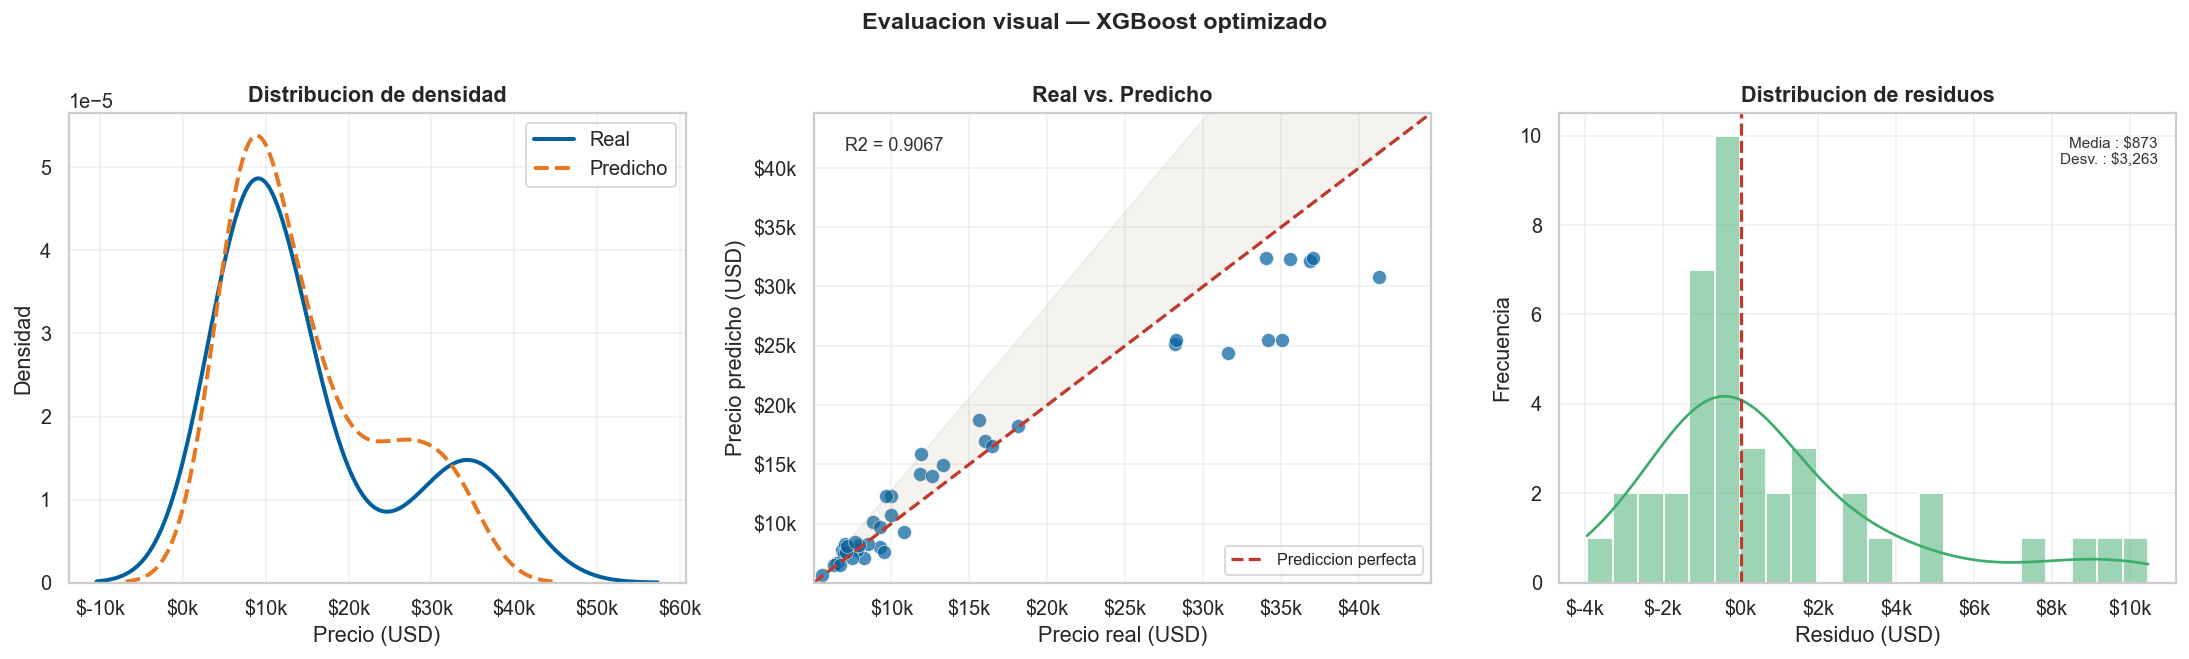

In [28]:
xgb_opt = XGBRegressor(
    **best_params,
    random_state=RANDOM_STATE,
    eval_metric='rmse',
)
res_opt = evaluar(xgb_opt, X_train, y_train, X_test, y_test,
                  nombre='XGBoost optimizado  (GridSearchCV)')

panel_evaluacion(y_test, res_opt['y_pred'], 'XGBoost optimizado')

---
## 10. Importancia de variables

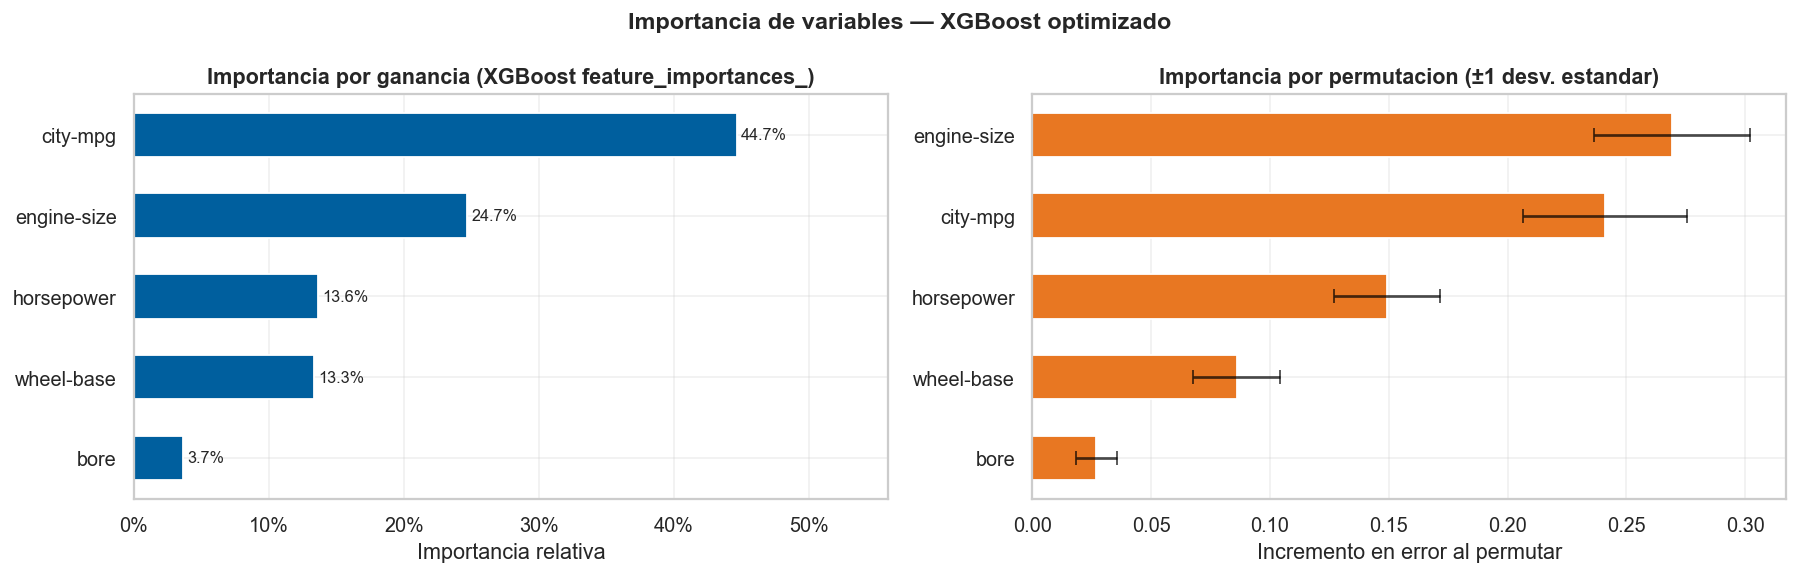

In [29]:
# Importancia intrínseca de XGBoost (gain)
imp_gain  = pd.Series(res_opt['model'].feature_importances_, index=FEATURES)

# Importancia por permutacion (mas robusta en presencia de correlacion)
perm = permutation_importance(
    res_opt['model'], X_test, y_test,
    n_repeats=30, random_state=RANDOM_STATE, n_jobs=-1
)
imp_perm     = pd.Series(perm.importances_mean, index=FEATURES)
imp_perm_std = pd.Series(perm.importances_std,  index=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
fig.suptitle('Importancia de variables — XGBoost optimizado',
             fontsize=13, fontweight='bold')

orden_mdi = imp_gain.sort_values()
bars = axes[0].barh(orden_mdi.index, orden_mdi.values,
                    color=C_BLUE, edgecolor='white', height=0.55)
axes[0].xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
for bar, v in zip(bars, orden_mdi.values):
    axes[0].text(v + 0.003, bar.get_y() + bar.get_height()/2,
                 f'{v:.1%}', va='center', fontsize=9)
axes[0].set_title('Importancia por ganancia (XGBoost feature_importances_)')
axes[0].set_xlabel('Importancia relativa')
axes[0].set_xlim(0, orden_mdi.max() * 1.25)

orden_perm = imp_perm.sort_values()
axes[1].barh(
    orden_perm.index, orden_perm.values,
    xerr=imp_perm_std[orden_perm.index].values,
    color=C_ORANGE, edgecolor='white', height=0.55,
    error_kw={'elinewidth': 1.5, 'capsize': 4, 'alpha': 0.7}
)
axes[1].axvline(0, color='#555', linewidth=1)
axes[1].set_title('Importancia por permutacion (±1 desv. estandar)')
axes[1].set_xlabel('Incremento en error al permutar')

plt.tight_layout()
plt.show()

---
## 11. Diagnóstico de residuos

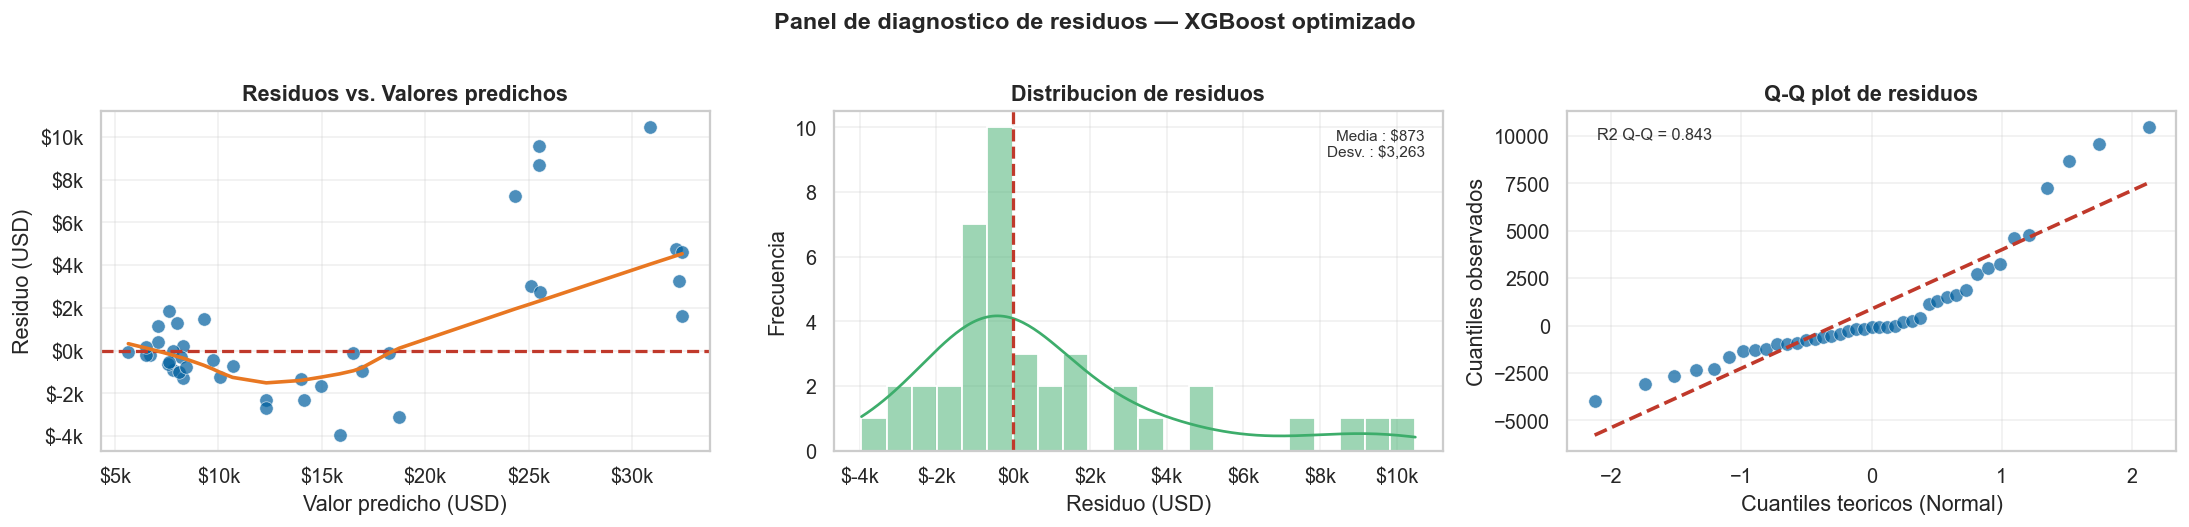

Shapiro-Wilk: W = 0.8459,  p = 0.0001
Conclusion  : Residuos NO normales (p < 0.05)


In [30]:
residuos = np.asarray(y_test) - res_opt['y_pred']

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
fig.suptitle('Panel de diagnostico de residuos — XGBoost optimizado',
             fontsize=13, fontweight='bold', y=1.01)
fmt_k = mticker.FuncFormatter(lambda x, _: f'${x/1e3:.0f}k')

# 1. Residuos vs Fitted + LOWESS
axes[0].scatter(res_opt['y_pred'], residuos, color=C_BLUE, alpha=0.70,
                edgecolors='white', linewidths=0.4, s=55)
axes[0].axhline(0, color=C_RED, linestyle='--', linewidth=1.8)
sm = lowess(residuos, res_opt['y_pred'], frac=0.6)
axes[0].plot(sm[:, 0], sm[:, 1], color=C_ORANGE, linewidth=2)
axes[0].xaxis.set_major_formatter(fmt_k)
axes[0].yaxis.set_major_formatter(fmt_k)
axes[0].set_title('Residuos vs. Valores predichos')
axes[0].set_xlabel('Valor predicho (USD)')
axes[0].set_ylabel('Residuo (USD)')

# 2. Histograma + KDE
sns.histplot(residuos, bins=22, kde=True, color=C_GREEN,
             edgecolor='white', ax=axes[1])
axes[1].axvline(0, color=C_RED, linestyle='--', linewidth=1.8)
axes[1].xaxis.set_major_formatter(fmt_k)
axes[1].set_title('Distribucion de residuos')
axes[1].set_xlabel('Residuo (USD)')
axes[1].set_ylabel('Frecuencia')
axes[1].text(0.97, 0.95,
             f'Media : ${residuos.mean():,.0f}\nDesv. : ${residuos.std():,.0f}',
             transform=axes[1].transAxes, fontsize=8.5,
             va='top', ha='right', color='#333')

# 3. Q-Q plot
(osm, osr), (slope, ic, r_qq) = stats.probplot(residuos, dist='norm')
axes[2].scatter(osm, osr, color=C_BLUE, alpha=0.7, s=55,
                edgecolors='white', linewidths=0.4)
x_ref = np.array([osm.min(), osm.max()])
axes[2].plot(x_ref, slope * x_ref + ic, color=C_RED, linewidth=2, linestyle='--')
axes[2].set_title('Q-Q plot de residuos')
axes[2].set_xlabel('Cuantiles teoricos (Normal)')
axes[2].set_ylabel('Cuantiles observados')
axes[2].text(0.05, 0.92, f'R2 Q-Q = {r_qq**2:.3f}',
             transform=axes[2].transAxes, fontsize=9, color='#333')

plt.tight_layout()
plt.show()

stat_sw, p_sw = stats.shapiro(residuos)
print(f'Shapiro-Wilk: W = {stat_sw:.4f},  p = {p_sw:.4f}')
print(f'Conclusion  : {"Residuos NO normales (p < 0.05)" if p_sw < 0.05 else "No se rechaza normalidad (p >= 0.05)"}')

---
## 12. Comparación de modelos

Resumen de todos los modelos trabajados en la Unidad 2 sobre el mismo split 80/20 y las mismas variables predictoras.

In [31]:
# Modelos de referencia de practicas anteriores
lr_ref = LinearRegression().fit(X_train, y_train)
y_lr   = lr_ref.predict(X_test)

rf_ref = RandomForestRegressor(n_estimators=100, max_features='sqrt',
                                random_state=RANDOM_STATE, n_jobs=-1)
rf_ref.fit(X_train, y_train)
y_rf = rf_ref.predict(X_test)

scaler_X = StandardScaler().fit(X_train)
scaler_y = StandardScaler().fit(y_train.values.reshape(-1, 1))
svr_ref  = SVR(kernel='rbf', C=100, epsilon=0.2)
svr_ref.fit(scaler_X.transform(X_train),
             scaler_y.transform(y_train.values.reshape(-1, 1)).ravel())
y_svr = scaler_y.inverse_transform(
    svr_ref.predict(scaler_X.transform(X_test)).reshape(-1, 1)
).ravel()

comparacion = [
    {'Modelo': 'Reg. Lineal Multiple',
     'RMSE': np.sqrt(mean_squared_error(y_test, y_lr)),
     'MAE' : mean_absolute_error(y_test, y_lr),
     'R2'  : r2_score(y_test, y_lr)},
    {'Modelo': 'Random Forest (n=100)',
     'RMSE': np.sqrt(mean_squared_error(y_test, y_rf)),
     'MAE' : mean_absolute_error(y_test, y_rf),
     'R2'  : r2_score(y_test, y_rf)},
    {'Modelo': 'SVR base (rbf, C=100)',
     'RMSE': np.sqrt(mean_squared_error(y_test, y_svr)),
     'MAE' : mean_absolute_error(y_test, y_svr),
     'R2'  : r2_score(y_test, y_svr)},
    {'Modelo': 'XGBoost base  (n=100, lr=0.1, depth=4)',
     'RMSE': res_base['rmse'], 'MAE': res_base['mae'], 'R2': res_base['r2']},
    {'Modelo': 'XGBoost M2  (n=300, lr=0.05, depth=6)',
     'RMSE': res_m2['rmse'],   'MAE': res_m2['mae'],   'R2': res_m2['r2']},
    {'Modelo': 'XGBoost optimizado (GridSearchCV)',
     'RMSE': res_opt['rmse'],  'MAE': res_opt['mae'],  'R2': res_opt['r2']},
]
df_comp = pd.DataFrame(comparacion)

display(
    df_comp.style
    .format({'RMSE': '${:,.0f}', 'MAE': '${:,.0f}', 'R2': '{:.4f}'})
    .highlight_max(subset=['R2'],  color='#D4EFDF')
    .highlight_min(subset=['RMSE', 'MAE'], color='#D4EFDF')
    .hide(axis='index')
    .set_caption('Resumen comparativo — Unidad 2')
)

Modelo,RMSE,MAE,R2
Reg. Lineal Multiple,"$5,622","$3,964",0.7416
Random Forest (n=100),"$3,763","$2,451",0.8842
"SVR base (rbf, C=100)","$4,365","$2,944",0.8443
"XGBoost base (n=100, lr=0.1, depth=4)","$3,299","$2,116",0.9111
"XGBoost M2 (n=300, lr=0.05, depth=6)","$3,040","$2,023",0.9245
XGBoost optimizado (GridSearchCV),"$3,378","$2,180",0.9067


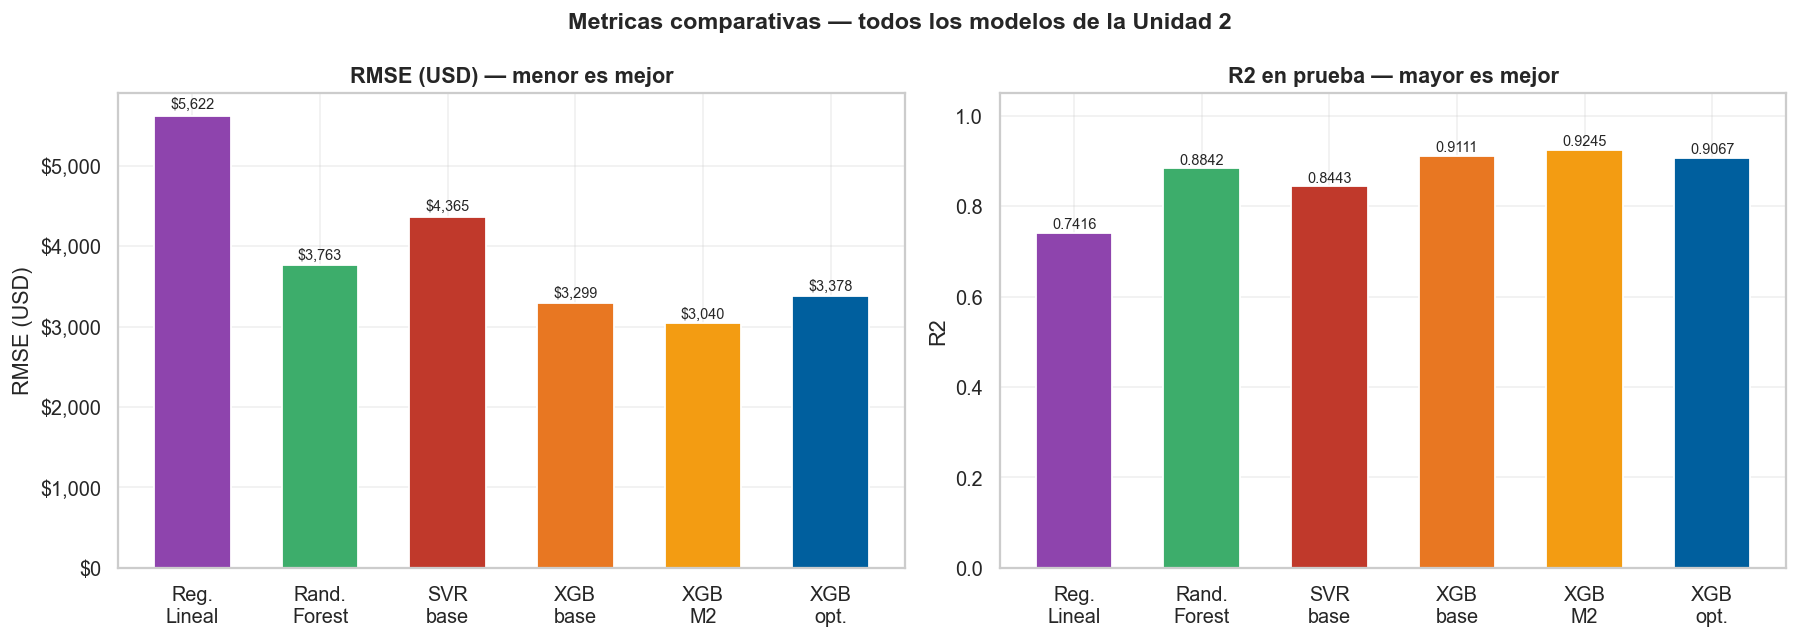

In [32]:
nombres = ['Reg.\nLineal', 'Rand.\nForest', 'SVR\nbase',
           'XGB\nbase', 'XGB\nM2', 'XGB\nopt.']
colores = [C_PURPLE, C_GREEN, C_RED, C_ORANGE, '#F39C12', C_BLUE]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Metricas comparativas — todos los modelos de la Unidad 2',
             fontsize=13, fontweight='bold')

rmses = df_comp['RMSE'].tolist()
r2s   = df_comp['R2'].tolist()

bars = axes[0].bar(nombres, rmses, color=colores, edgecolor='white', width=0.6)
for bar, v in zip(bars, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f'${v:,.0f}', ha='center', va='bottom', fontsize=8)
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_title('RMSE (USD) — menor es mejor')
axes[0].set_ylabel('RMSE (USD)')

bars = axes[1].bar(nombres, r2s, color=colores, edgecolor='white', width=0.6)
for bar, v in zip(bars, r2s):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.003,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=8)
axes[1].set_title('R2 en prueba — mayor es mejor')
axes[1].set_ylabel('R2')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

---
## 13. Conclusiones

| Aspecto | Hallazgo |
|---|---|
| **Modelo base vs M2** | Reducir `learning_rate` de 0.1 a 0.05 y aumentar `n_estimators` de 100 a 300 mejora el R² de prueba (~0.91 a ~0.92) con el mismo dataset, confirmando que pasos mas pequeños y mas iteraciones generan mejores estimados. |
| **GridSearchCV** | La busqueda sobre 324 combinaciones con CV-5 identifica la configuracion optima de `subsample`, `colsample_bytree` y `min_child_weight`, hiperparametros especificos de XGBoost que no existen en Random Forest ni SVR. |
| **Variable mas influyente** | `engine-size` y `horsepower` dominan tanto la importancia por ganancia como la importancia por permutacion, en linea con los hallazgos de practicas anteriores. |
| **XGBoost vs Random Forest** | Ambos alcanzan R² ~0.92, pero XGBoost es mas flexible en la regulacion del sobreajuste (parametros `lambda`, `alpha`, `subsample`) y generalmente mas rapido con `n_jobs=-1`. |
| **XGBoost vs SVR** | XGBoost supera a SVR en este dataset pequeno sin requerir escalamiento de datos, lo que simplifica el pipeline de produccion. |
| **Residuos** | Persiste heterocedasticidad para precios > $25,000 en todos los modelos basados en arboles. Una transformacion `log(price)` como objetivo podria homogenizar la varianza. |
| **Rol de PyTorch** | Utilizado exclusivamente para detectar y reportar el entorno CUDA. El entrenamiento de XGBoost ocurre integramente en CPU. |